In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [3]:
data_file_path = '/Volumes/T7/radar_tutorial_data/ExampleIQData.mat'
video_file_path = '/Volumes/T7/radar_tutorial_data/ExampleVideoData.mp4'

radar_config = {
    "StartFrequency_GHz": 77.0,
    "StopFrequency_GHz": 78.775,
    "CenterFrequency_GHz": 77.975,
    "Bandwidth_GHz": 1.6,
    "RampTime_us": 75.0,
    "ChirpCycleTime_us": 225.0,
    "SweepSlope_MHz_per_us": 25.0,
    "SamplesPerChirp": 400,
    "ADCSampleRate_ksps": 6250.0, # ksps - kilo (1000) samples per second 
    "NumChirps": 80,
    "NumReceivers": 4,
    "ActiveReceivers": [1, 1, 1, 1],
    "NumTransmitters": 2,
    "ActiveTransmitters": [1, 1],
    "FramePeriodicity_ms": 100.0,
    "MaximumRange_m": 37.4741,
    "RangeResolution_m": 0.093685,
    "AzimuthResolution_deg": 14.4775,
    "MaximumRangeRate_m_per_s": 2.136,
    "RangeRateResolution_m_per_s": 0.1068
}


wavelength = 3*10e8 / (77*10e9) 

# sampling rate (Samples/s)
fs = radar_config['ADCSampleRate_ksps']*1e3
# sweep slope (Hz/s)
sweep_slope = radar_config['SweepSlope_MHz_per_us']*1e6/1e-6
# center frequncy (Hz)
fc = radar_config['CenterFrequency_GHz']*1e9
# PRF (Hz)
prf = 1e6 / (radar_config['NumTransmitters']*radar_config['ChirpCycleTime_us'])
c = 3e8

In [4]:
# create virtual array based on transmitter and receiver positions
n_tx = radar_config['NumTransmitters'] # number of transmitter antennas
n_rx = radar_config['NumReceivers'] # number of receiver antennas
virtual_array_size = n_tx * n_rx # number of virtual receiver antennas
virtual_pos = np.zeros((3, virtual_array_size)) 

tx_pos = np.zeros((3, n_tx))
for i in range(n_tx):
    tx_pos[:, i] = [0, -wavelength + i*2*wavelength, 0] # transmitter antennas are sparated by 2*wavelength

rx_pos = np.zeros((3, n_rx))
for i in range(n_rx):
    rx_pos[:, i] = [0, -0.0029 + i*0.5*wavelength, 0] # receiver antennas are separated by half a wavelength

for i in range(n_tx):
    start_idx = i*n_rx
    end_idx = start_idx+n_rx
    virtual_pos[:,start_idx:end_idx] = rx_pos + tx_pos[:, i:i+1] # position of virtual antennas in the array

In [5]:
def load_and_virtualize(file_path: str, data_name: str, radar_config: dict):
    """
        Function to load FMCW radar frame and organize data in the virtual antenna array. 
    """
    data = loadmat(file_path)[data_name]
    n_samples = radar_config['SamplesPerChirp']
    n_chirps = radar_config['NumChirps']
    n_chirps_per_tx = n_chirps//n_tx
    virtual_data = np.zeros((n_samples, n_rx*n_tx, n_chirps//n_tx), dtype=data.dtype)
    
    for i in range(n_tx):
        start_idx = i*n_rx
        end_idx = start_idx+n_rx
        virtual_data[:, start_idx:end_idx, :] = data[:, :, i:i + n_chirps_per_tx*n_tx:n_tx]

    return virtual_data

virutal_data = load_and_virtualize(data_file_path, 'dataSnapshot', radar_config)
virutal_data.shape # expected: (400, 8, 40) = (num_samples_per_chirp, num_virutal_antennas, num_chirps_per_frame) 

(400, 8, 40)

## Stationary Target

In [6]:
stationary_reflector_data = load_and_virtualize(data_file_path, 'stationaryReflectorData', radar_config)
stationary_reflector_data.shape

(400, 8, 40)

In [7]:
# range vector - bins of range FFT converted to actual range values in meters
# formula: (k_i*c_speed*f_s) / (2*n_samples*sweep_slope) = (delta_f * c_speed) / (2*sweep_slope)
# k_i = i-th bin of FFT (number of bins equals number of sampels)
# c_speed = speed of light
# f_s = sampling rate in the fast time
# sweep_slope = slope of the FM chirp
# n_samples = number of samples in a single chirp
n_samples = radar_config['SamplesPerChirp']
range_vec = np.arange(n_samples) * c * fs / (2 * sweep_slope * n_samples)

# velocity vector - bins of two-sided FFT converted to actual velocity values in m/s
# formula: -f_doppler * wavelength / 2
# f_doppler - computed from FFT
n_chirps_per_tx = radar_config['NumChirps']//n_tx
doppler_freq = np.fft.fftfreq(n_chirps_per_tx, d=1/prf)
doppler_freq = np.fft.fftshift(doppler_freq)
speed_vec = -doppler_freq * wavelength / 2

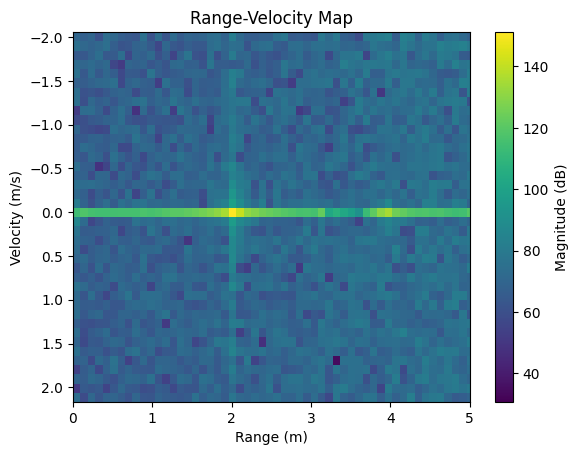

In [8]:
def compute_range_doppler_maps(data):
    """
        Computes range-doppler map.
    Args:
        data: matrix of shape (n_samples_per_chirp, n_virt_antennas, n_chirps_per_frame)
    Returns:
       range-doppler map
    """
    range_doppler_maps = np.zeros_like(data, dtype=data.dtype)
    for i in range(range_doppler_maps.shape[1]): # for every antenna
        range_fft = np.fft.fft(data[:,i,:], axis=0) # for each column do the fft
        range_doppler = np.fft.fft(range_fft, axis=1) # for each row do the fft
        range_doppler = np.fft.fftshift(range_doppler, axes=1)
        range_doppler_maps[:, i, :] = range_doppler

    return range_doppler_maps

def visualize_range_doppler_map(range_doppler_map):
    extent = [
        range_vec[0],
        range_vec[-1],
        speed_vec[0],
        speed_vec[-1]
    ]

    plt.figure()
    plt.imshow(20 * np.log10(np.abs(range_doppler_map.T) + 1e-12), aspect='auto', origin='lower', extent=extent)
    plt.colorbar(label='Magnitude (dB)')
    plt.xlim(0, 5.0)
    plt.ylabel('Velocity (m/s)')
    plt.xlabel('Range (m)')
    plt.title('Range-Velocity Map')
    plt.show()

range_doppler_maps = compute_range_doppler_maps(stationary_reflector_data)
visualize_range_doppler_map(range_doppler_maps[:,0,:])
# Observation from the plot: Target is located 2 meters ahead of the radar and it is stationary.

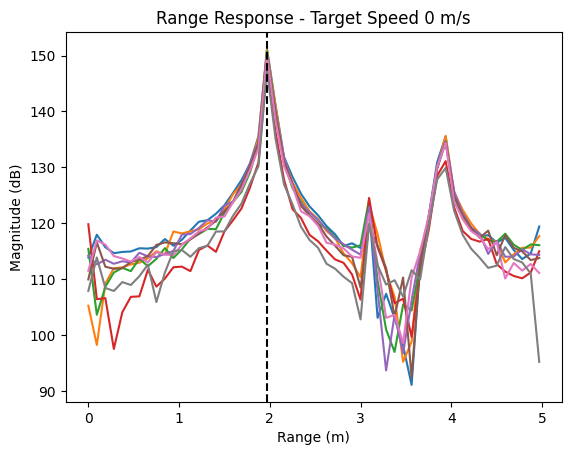

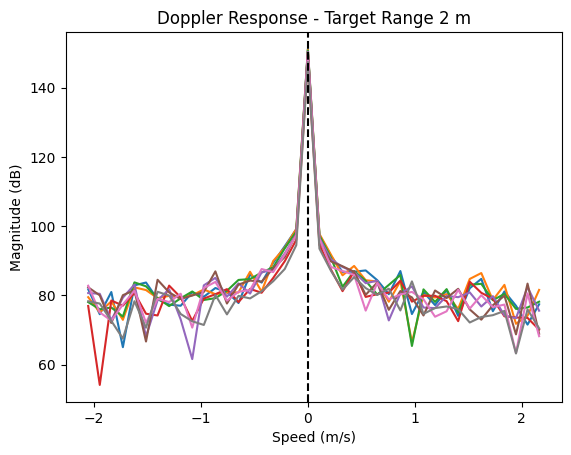

In [9]:
visible_range_idx = (range_vec >= 0) & (range_vec <= 5.0)
visible_range = range_vec[visible_range_idx]
visible_range_doppler_map = range_doppler_maps[visible_range_idx, :, :]

# Zero-Doppler bin is the center after fftshift
zero_doppler_idx = n_chirps_per_tx // 2
two_meter_idx = np.argmin(np.abs(range_vec - 2.0))

# visualize range response for each antenna
plt.figure()
for i in range(visible_range_doppler_map.shape[1]):
    plt.plot(visible_range, 20 * np.log10(np.abs(visible_range_doppler_map[:, i, zero_doppler_idx]) + 1e-12))
plt.axvline(x=range_vec[two_meter_idx], color='k', linestyle='--', label='Target range (2 m)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Range (m)')
plt.title('Range Response - Target Speed 0 m/s')
plt.show()

# visualize doppler response
plt.figure()
for i in range(visible_range_doppler_map.shape[1]):
    plt.plot(speed_vec, 20 * np.log10(np.abs(visible_range_doppler_map[two_meter_idx, i, :]) + 1e-12))
plt.axvline(x=speed_vec[zero_doppler_idx], color='k', linestyle='--', label='Target speed (0 m/s)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Speed (m/s)')
plt.title('Doppler Response - Target Range 2 m')
plt.show()

## Moving Target

In [10]:
# MOVING REFLECTOR
moving_reflector_data = load_and_virtualize(data_file_path, 'movingReflectorData', radar_config)
moving_reflector_data.shape

(400, 8, 40)

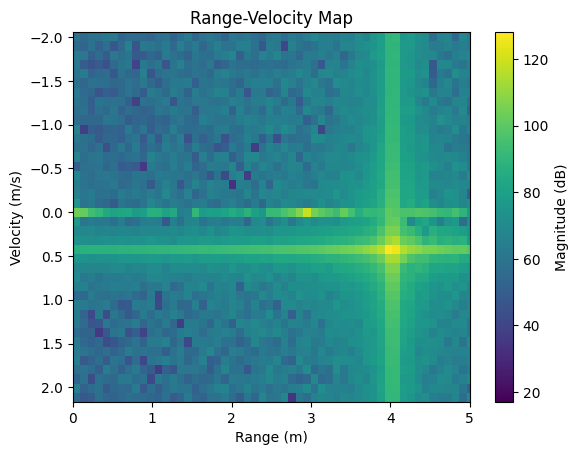

In [11]:
range_doppler_maps = compute_range_doppler_maps(moving_reflector_data)
visualize_range_doppler_map(range_doppler_maps[:,0,:])
# Observation from the plot: Target is located 4 meters ahead of radar and it has radial velocity of approximately 0.4 meters

In [12]:
visible_range_idx = (range_vec >= 0) & (range_vec <= 5.0)
visible_range = range_vec[visible_range_idx]
visible_range_doppler_map = range_doppler_maps[visible_range_idx, :, :]

four_meter_idx = np.argmin(np.abs(range_vec - 4))       # range bin closest to 4 meters
target_speed_idx = np.argmin(np.abs(speed_vec - 0.4))   # Doppler bin closest to 0.4 m/s
speed_vec[target_speed_idx]

np.float64(0.4329004329004329)

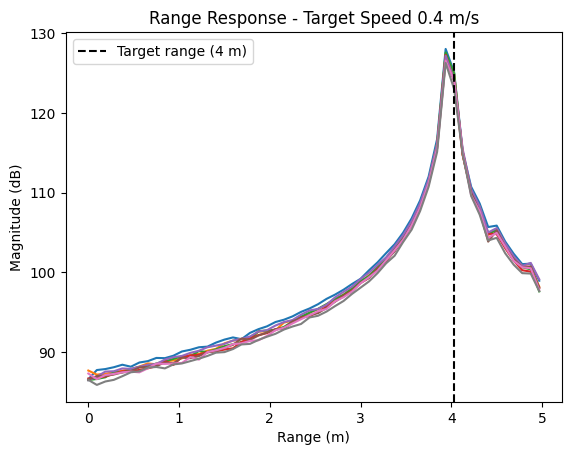

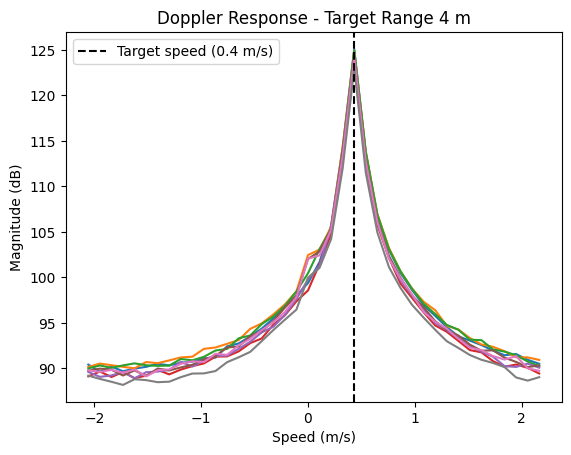

In [13]:
plt.figure()
for i in range(8):
    plt.plot(visible_range, 20 * np.log10(np.abs(visible_range_doppler_map[:, i, target_speed_idx]) + 1e-12))
plt.axvline(x=range_vec[four_meter_idx], color='k', linestyle='--', label='Target range (4 m)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Range (m)')
plt.title('Range Response - Target Speed 0.4 m/s')
plt.legend()
plt.show()

plt.figure()
for i in range(8):
    plt.plot(speed_vec, 20 * np.log10(np.abs(range_doppler_maps[four_meter_idx, i, :]) + 1e-12))
plt.axvline(x=speed_vec[target_speed_idx], color='k', linestyle='--', label='Target speed (0.4 m/s)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Speed (m/s)')
plt.title('Doppler Response - Target Range 4 m')
plt.legend()
plt.show()

## Windowing Function

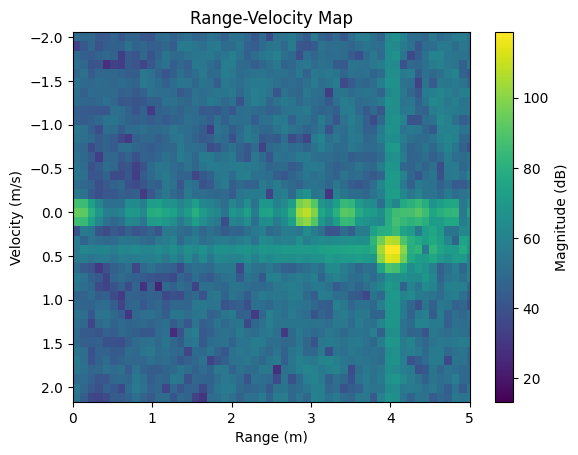

In [14]:
moving_reflector_data = load_and_virtualize(data_file_path, 'movingReflectorData', radar_config)

range_doppler_maps = np.zeros_like(moving_reflector_data, dtype=moving_reflector_data.dtype)
for i in range(range_doppler_maps.shape[1]): # for every antenna
    range_window = np.hamming(n_samples)
    range_fft = np.fft.fft(moving_reflector_data[:,i,:]*range_window[:, np.newaxis], axis=0) 
    
    doppler_window = np.hamming(n_chirps_per_tx)
    range_doppler = np.fft.fft(range_fft*doppler_window[np.newaxis, :], axis=1)
    range_doppler = np.fft.fftshift(range_doppler, axes=1)
    range_doppler_maps[:, i, :] = range_doppler

visualize_range_doppler_map(range_doppler_maps[:,0,:])

In [15]:
visible_range_idx = (range_vec >= 0) & (range_vec <= 5.0)
visible_range = range_vec[visible_range_idx]
visible_range_doppler_map = range_doppler_maps[visible_range_idx, :, :]

four_meter_idx = np.argmin(np.abs(range_vec - 4))       # range bin closest to 4 meters
target_speed_idx = np.argmin(np.abs(speed_vec - 0.4))   # Doppler bin closest to 0.4 m/s
speed_vec[target_speed_idx]

np.float64(0.4329004329004329)

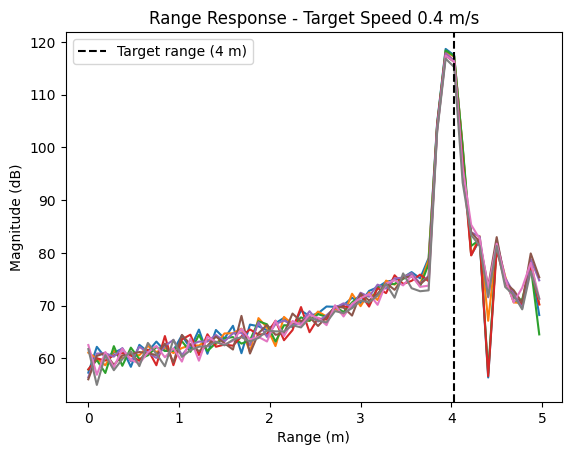

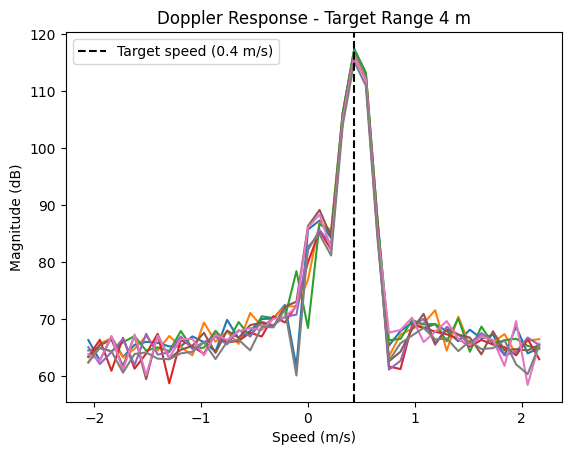

In [16]:
plt.figure()
for i in range(8):
    plt.plot(visible_range, 20 * np.log10(np.abs(visible_range_doppler_map[:, i, target_speed_idx]) + 1e-12))
plt.axvline(x=range_vec[four_meter_idx], color='k', linestyle='--', label='Target range (4 m)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Range (m)')
plt.title('Range Response - Target Speed 0.4 m/s')
plt.legend()
plt.show()

plt.figure()
for i in range(8):
    plt.plot(speed_vec, 20 * np.log10(np.abs(range_doppler_maps[four_meter_idx, i, :]) + 1e-12))
plt.axvline(x=speed_vec[target_speed_idx], color='k', linestyle='--', label='Target speed (0.4 m/s)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Speed (m/s)')
plt.title('Doppler Response - Target Range 4 m')
plt.legend()
plt.show()

## Angle Response

### Angle response from a single transmit-receiver group

In [17]:
# Angle data
angle_target_data = load_and_virtualize(data_file_path, 'angleTargetData', radar_config)
angle_target_data.shape

(400, 8, 40)

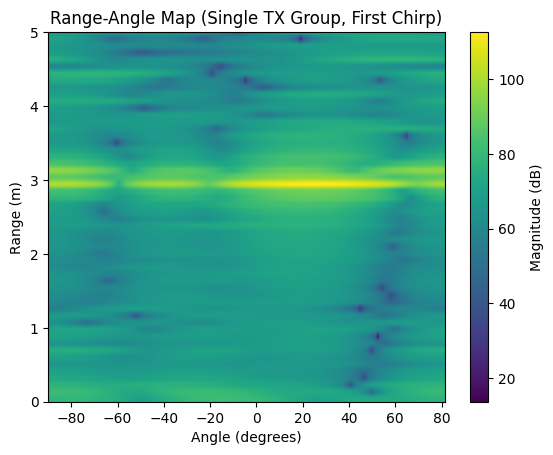

In [18]:
first_tx_group_data = angle_target_data[:, :4, 0]  # (400, 4) - first chirp, first TX group

# Range FFT along axis 0 (fast-time)
range_fft = np.fft.fft(first_tx_group_data, axis=0)

# Angle FFT along axis 1 (antenna) with zero-padding + fftshift
n_angle_fft = 180
range_angle_map = np.fft.fftshift(np.fft.fft(range_fft, n=n_angle_fft, axis=1), axes=1)

# compute angle vector
d = wavelength/2 # separation between antennas is half a wavelength
spatial_freq = np.arange(n_angle_fft) / n_angle_fft - 0.5
sin_theta = spatial_freq * (wavelength / d) 
angle_vec = np.rad2deg(np.arcsin(sin_theta))

def visualize_range_angle_map(range_angle_map):
    extent = [
        angle_vec[0],
        angle_vec[-1],
        range_vec[0],
        range_vec[-1],
    ]

    plt.figure()
    plt.imshow(20 * np.log10(np.abs(range_angle_map) + 1e-12), aspect='auto', origin='lower', extent=extent)
    plt.colorbar(label='Magnitude (dB)')
    plt.ylim(0, 5.0)
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Range (m)')
    plt.title('Range-Angle Map (Single TX Group, First Chirp)')
    plt.show()

visualize_range_angle_map(range_angle_map)

Target range: 2.91 m, Target angle: 19.47 deg


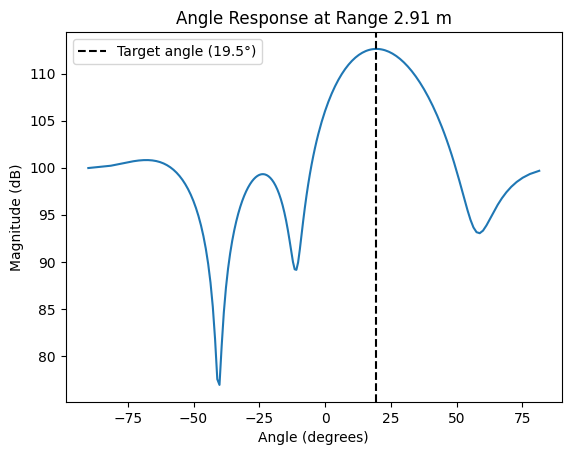

In [19]:
visible_range_idx = (range_vec >= 0) & (range_vec <= 5.0)
visible_range = range_vec[visible_range_idx]
visible_range_angle_map = range_angle_map[visible_range_idx, :]

# location of the maximum response
target_idx = np.unravel_index(np.argmax(np.abs(visible_range_angle_map)), visible_range_angle_map.shape)
target_range = visible_range[target_idx[0]]
target_angle = angle_vec[target_idx[1]]
print(f"Target range: {target_range:.2f} m, Target angle: {target_angle:.2f} deg")

# Angle response at the target's range bin
target_angle_response = visible_range_angle_map[target_idx[0], :] 

plt.figure()
plt.plot(angle_vec, 20 * np.log10(np.abs(target_angle_response) + 1e-12))
plt.axvline(x=target_angle, color='k', linestyle='--', label=f'Target angle ({target_angle:.1f}°)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Angle (degrees)')
plt.title(f'Angle Response at Range {target_range:.2f} m')
plt.legend()
plt.show()

### Angle response for a virtual array

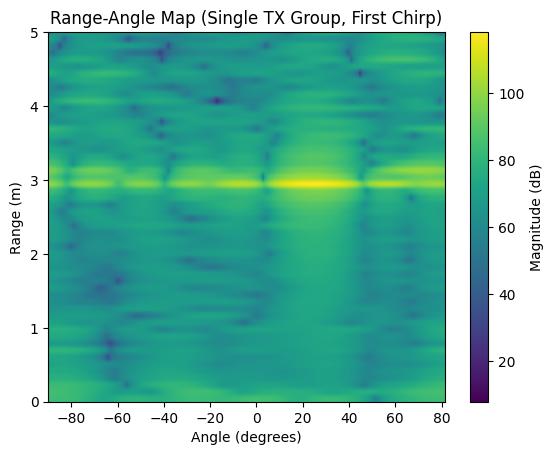

In [20]:
whole_array_data = angle_target_data[:, :, 0]

# Range FFT along axis 0 (fast-time)
range_fft = np.fft.fft(whole_array_data, axis=0)

# Angle FFT along axis 1 (antenna) with zero-padding + fftshift
n_angle_fft = 180
range_angle_map = np.fft.fftshift(np.fft.fft(range_fft, n=n_angle_fft, axis=1), axes=1)

visualize_range_angle_map(range_angle_map)

Target range: 2.91 m, Target angle: 19.47 deg


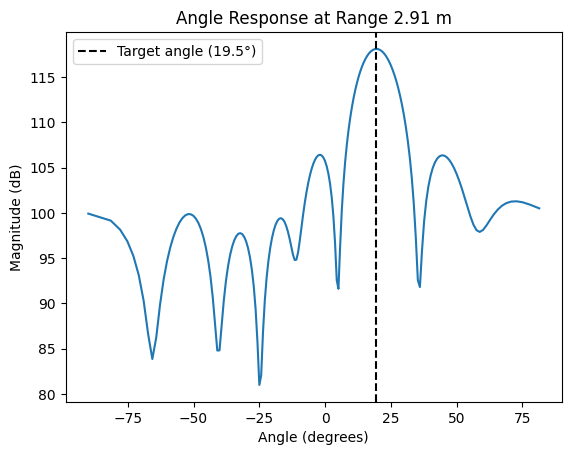

In [21]:
visible_range_idx = (range_vec >= 0) & (range_vec <= 5.0)
visible_range = range_vec[visible_range_idx]
visible_range_angle_map = range_angle_map[visible_range_idx, :]

# location of the maximum response
target_idx = np.unravel_index(np.argmax(np.abs(visible_range_angle_map)), visible_range_angle_map.shape)
target_range = visible_range[target_idx[0]]
target_angle = angle_vec[target_idx[1]]
print(f"Target range: {target_range:.2f} m, Target angle: {target_angle:.2f} deg")

# Angle response at the target's range bin
target_angle_response = visible_range_angle_map[target_idx[0], :] 

plt.figure()
plt.plot(angle_vec, 20 * np.log10(np.abs(target_angle_response) + 1e-12))
plt.axvline(x=target_angle, color='k', linestyle='--', label=f'Target angle ({target_angle:.1f}°)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Angle (degrees)')
plt.title(f'Angle Response at Range {target_range:.2f} m')
plt.legend()
plt.show()

## Detection Generation

##### Load Data and Virtualize Data

In [22]:
people_raw = loadmat(data_file_path)['peopleDetectionData']['data'].squeeze(0)
n_frames = len(people_raw)

n_samples = radar_config['SamplesPerChirp']
n_chirps = radar_config['NumChirps']
n_chirps_per_tx = n_chirps // n_tx

people_frames = np.zeros((n_frames, n_samples, n_rx * n_tx, n_chirps_per_tx), dtype=np.complex128)

# organize data into virtual array
for frame_idx in range(n_frames):
    raw_frame = people_raw[frame_idx]  
    for tx_idx in range(n_tx):
        start_idx = tx_idx * n_rx
        end_idx = start_idx + n_rx
        people_frames[frame_idx, :, start_idx:end_idx, :] = raw_frame[:, :, tx_idx::n_tx]


##### Moving Target Indicator (MTI) Filter

In [23]:
people_frames_filtered = people_frames[..., 2:] - 2*people_frames[..., 1:-1] + people_frames[..., :-2]
people_frames_filtered.shape

(100, 400, 8, 38)

##### Range-Doppler Processing

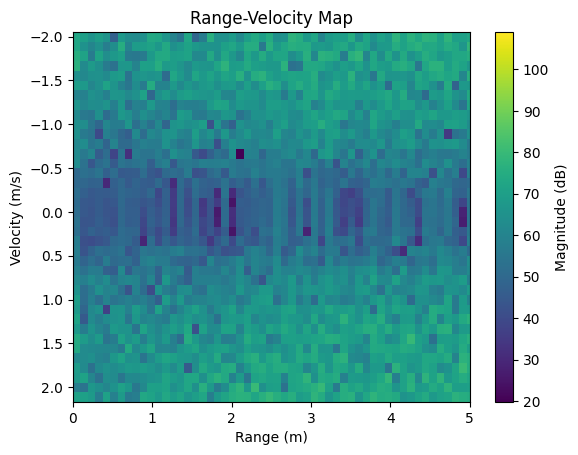

In [103]:
people_range_doppler_map = compute_range_doppler_maps(people_frames_filtered[81])
visualize_range_doppler_map(people_range_doppler_map[:,0,:])

##### Beamforming

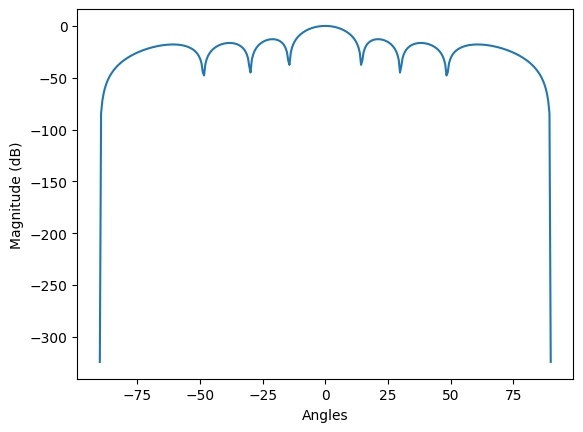

In [104]:
angles = np.linspace(-90, 90, 360)
AF = np.zeros_like(angles, dtype=np.complex64)

d = wavelength / 2 # spacing between antennas

for idx, angle in enumerate(angles):
    af_i = 0j
    for k in range(virtual_array_size):
        af_i += np.exp(2j*np.pi*k*(d/wavelength)*np.sin(np.deg2rad(angle)))
    AF[idx] = af_i

plt.figure()
plt.plot(angles, 20 * np.log10(np.abs(AF) / np.max(np.abs(AF))))
plt.ylabel('Magnitude (dB)')
plt.xlabel('Angles')
plt.title('')
plt.show()


In [105]:
AF_dB = 20 * np.log10(np.abs(AF) / np.max(np.abs(AF)))
main_lobe_mask = AF_dB >= -9
main_lobe_angles = angles[main_lobe_mask]
beamwidth = main_lobe_angles[-1] - main_lobe_angles[0]
print(f"9 dB beamwidth: {beamwidth:.1f} degrees")

fov_start = -30
fov_stop = 30
beamforming_angles = np.arange(fov_start + beamwidth/2, fov_stop - beamwidth/2 + 1, beamwidth/2)
print(f"Beamforming angles: {beamforming_angles}")

9 dB beamwidth: 19.6 degrees
Beamforming angles: [-20.22284123 -10.44568245  -0.66852368   9.1086351   18.88579387]


In [106]:
# steering vectors
w = np.zeros((beamforming_angles.shape[0], virtual_array_size), dtype=np.complex64)

for angle_idx, angle in enumerate(beamforming_angles):
    w[angle_idx] = [np.exp(2j*np.pi*k*(d/wavelength)*np.sin(np.deg2rad(angle))) for k in range(virtual_array_size)]

beamformed_range_doppler_maps = (people_range_doppler_map.transpose((0, 2, 1)) @ w.T.conj()).transpose((0, 2, 1))


##### 2D Constant False Alarm (CFAR) Detector

In [107]:
# update speed vector due to MTI filter and transient pulse
n_doppler_bins = people_frames_filtered.shape[-1]  # 38
doppler_freq = np.fft.fftshift(np.fft.fftfreq(n_doppler_bins, d=1/prf))
speed_vec = -doppler_freq * wavelength / 2
len(speed_vec)

38

In [108]:
def cfar(range_doppler_maps, range_guard=5, doppler_guard=1, range_train=10, doppler_train=2,
        min_range=1, max_range=15, min_speed=0.2, max_speed=np.inf):

    n_train_cells = (2*range_train + 2*range_guard + 1)*(2*doppler_train + 2*doppler_guard + 1) - (2*range_guard+1)*(2*doppler_guard+1)


    min_range_cell = range_guard + range_train
    max_range_cell = len(range_vec) - range_guard - range_train - 1
    min_doppler_cell = doppler_guard + doppler_train
    max_doppler_cell = len(speed_vec) - doppler_guard - doppler_train - 1

    power_maps = np.abs(range_doppler_maps)**2
    detection_mask = np.zeros_like(power_maps)

    threshold_factor = 10**(15/10)

    for i in range(power_maps.shape[1]):
        power_map = power_maps[:,i,:]

        for r_idx in range(min_range_cell, max_range_cell+1):
            if not (min_range <= range_vec[r_idx] <= max_range):
                continue

            for d_idx in range(min_doppler_cell, max_doppler_cell+1):
                if not (min_speed <= np.abs(speed_vec[d_idx]) <= max_speed):
                    continue

                window_total = power_map[r_idx-range_guard-range_train:r_idx+range_guard+range_train+1, 
                                        d_idx-doppler_guard-doppler_train:d_idx+doppler_guard+doppler_train+1]
                total_power = np.sum(window_total)

                window_guard = power_map[r_idx-range_guard:r_idx+range_guard+1, 
                                        d_idx-doppler_guard:d_idx+doppler_guard+1]
                guard_power = np.sum(window_guard)

                noise_power = total_power - guard_power
                noise_power /= n_train_cells
                if power_map[r_idx,d_idx] > threshold_factor*noise_power:
                    detection_mask[r_idx,i,d_idx] = 1

    return detection_mask

detection_mask = cfar(beamformed_range_doppler_maps)

##### Direction of Arrival (DOA) Estimation

In [109]:
import warnings

def get_targets(detection_mask):
    detections = np.argwhere(detection_mask > 0) 

    doa_angles = np.arange(-90, 91)  
    doa_steering = np.zeros((len(doa_angles), virtual_array_size), dtype=np.complex128)
    for idx, angle in enumerate(doa_angles):
        for k in range(virtual_array_size):
            doa_steering[idx, k] = np.exp(2j * np.pi * k * (d/wavelength) * (np.sin(np.deg2rad(angle))))

    targets = []
    for range_idx, _, doppler_idx in detections:
        snapshot = people_range_doppler_map[range_idx,:,doppler_idx]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  
            spectrum = np.abs(doa_steering.conj() @ snapshot)**2
        estimated_angle = doa_angles[np.argmax(spectrum)]
        targets.append((range_vec[range_idx], speed_vec[doppler_idx], estimated_angle))

    return np.array(targets)

targets = get_targets(detection_mask)
for t in targets:
    print(f"  Range: {t[0]:.2f} m, Speed: {t[1]:.2f} m/s, Angle: {t[2]}°")

  Range: 6.84 m, Speed: 1.37 m/s, Angle: 15.0°
  Range: 6.84 m, Speed: 1.37 m/s, Angle: 15.0°
  Range: 6.84 m, Speed: 0.68 m/s, Angle: 17.0°
  Range: 6.84 m, Speed: 1.37 m/s, Angle: 15.0°
  Range: 6.84 m, Speed: 0.68 m/s, Angle: 17.0°
  Range: 6.94 m, Speed: 1.48 m/s, Angle: 14.0°
  Range: 6.94 m, Speed: 1.37 m/s, Angle: 15.0°
  Range: 6.94 m, Speed: 1.37 m/s, Angle: 15.0°
  Range: 6.94 m, Speed: 1.48 m/s, Angle: 14.0°
  Range: 6.94 m, Speed: 1.37 m/s, Angle: 15.0°
  Range: 6.94 m, Speed: 1.48 m/s, Angle: 14.0°
  Range: 6.94 m, Speed: 1.37 m/s, Angle: 15.0°
  Range: 7.03 m, Speed: 1.14 m/s, Angle: 18.0°
  Range: 7.03 m, Speed: 1.48 m/s, Angle: 14.0°
  Range: 7.03 m, Speed: 1.82 m/s, Angle: 15.0°
  Range: 10.41 m, Speed: -1.03 m/s, Angle: 39.0°
  Range: 10.41 m, Speed: -1.03 m/s, Angle: 39.0°
  Range: 10.50 m, Speed: -1.03 m/s, Angle: 39.0°
  Range: 10.50 m, Speed: -1.14 m/s, Angle: 39.0°
  Range: 10.50 m, Speed: -1.03 m/s, Angle: 39.0°
  Range: 10.50 m, Speed: -1.14 m/s, Angle: 39.0°


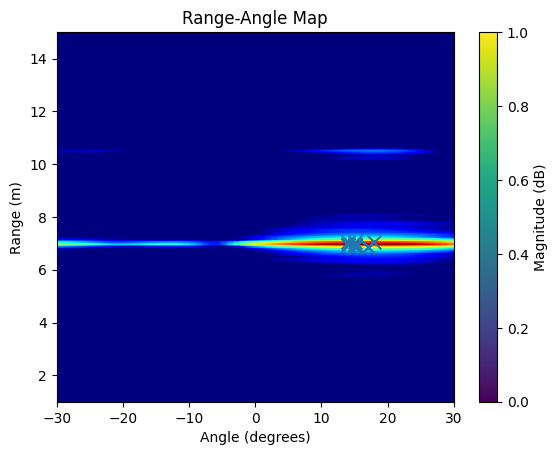

In [110]:
n_angle_fft = 180
angle_fft = np.fft.fft(people_range_doppler_map, n=n_angle_fft, axis=1)
angle_fft = np.fft.fftshift(angle_fft, axes=1)

people_range_angle_map = np.sum(np.abs(angle_fft)**2, axis=2)


extent = [
    angle_vec[0],
    angle_vec[-1],
    range_vec[0],
    range_vec[-1],
]

ra_db = 20 * np.log10(np.abs(people_range_angle_map) + 1e-12)

plt.figure()
plt.imshow(ra_db, vmax=ra_db.max(), vmin=ra_db.max()-60, aspect='auto', origin='lower', extent=extent, cmap='jet')
plt.scatter(targets[:, 2], targets[:, 0], marker='x', linewidths=1.5, s=100)
plt.colorbar(label='Magnitude (dB)')
plt.ylim(1, 15)
plt.xlim(fov_start, fov_stop)
plt.xlabel('Angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range-Angle Map')
plt.show()

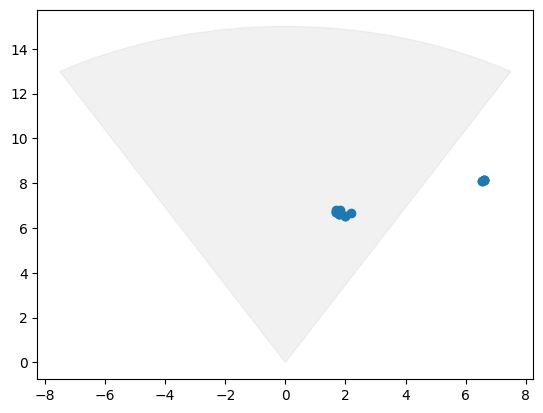

In [111]:
point_cloud = []
for target in targets:
    point_cloud.append([target[0]*np.sin(np.deg2rad(target[2])), target[0]*np.cos(np.deg2rad(target[2]))])

point_cloud = np.array(point_cloud)

fov_angles = np.deg2rad(np.linspace(fov_start, fov_stop, 200))
max_range = 15
x_arc = max_range*np.sin(fov_angles)
y_arc = max_range*np.cos(fov_angles)

plt.figure()
plt.fill([0, *x_arc, 0], [0, *y_arc, 0], color='lightgray', alpha=0.3)
plt.scatter(point_cloud[:, 0], point_cloud[:, 1])
plt.show()

In [12]:
import numpy as np

np.load('/Users/dino/Downloads/pc01p/1/rpc_00033.npy')[100]

array([ 9.69940637e+00, -6.29886814e+00,  4.03866246e-01,  9.14392838e-02,
       -1.43411751e+00,  1.15722656e+01, -5.75958653e-01,  3.49065850e-02,
        2.50000000e+01,  8.60000000e+01,  1.60000000e+01])